# 06. Interpretabilidad (SHAP y LIME)

SHAP global (summary plot) y local (waterfall, 2 observaciones: una bien clasificada y una con error alto) para el **mejor modelo** identificado en `05_results_analysis.ipynb`, más la comparación LIME vs. SHAP **específicamente para XGBoost** que pide el curso.

Trabaja desde `results/experiments_master.csv` (mismo patrón que `05_results_analysis.ipynb`), no depende de nada en memoria de notebooks anteriores.

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import numpy as np

from src import config
from src.data_loader import load_processed_dataset, split_features_target
from src.synthetic_data import generate_synthetic_dataset
from src.preprocessing import remove_duplicate_rows
from src.models import MODEL_REGISTRY
from src.experiment_runner import load_master_table
from src import interpretability as ip

np.random.seed(config.RANDOM_STATE)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

try:
    df = load_processed_dataset()
except FileNotFoundError:
    df = generate_synthetic_dataset()
df, _ = remove_duplicate_rows(df)
X, y = split_features_target(df)

table = load_master_table(config.EXPERIMENTS_MASTER_PATH)
if table.empty:
    raise RuntimeError("La tabla maestra está vacía. Correr primero 04_run_experiments.ipynb.")

## Elegir el mejor modelo y ajustar su pipeline

El fold externo usado es el de mejor desempeño (`{metric}_per_fold`, ver columna persistida por `nested_cv.py`); SHAP/LIME se calculan sobre ESE fold de prueba.

In [12]:
metric_for_ranking = config.DEFAULT_SCORING
best_row = table.sort_values(f"{metric_for_ranking}_mean", ascending=False).iloc[0]
best_model = best_row["model"]
best_technique = best_row["technique"]
best_method = best_row["method"]

best_params_per_fold = json.loads(best_row["best_params_per_fold"])
per_fold_metric = json.loads(best_row[f"{metric_for_ranking}_per_fold"])
best_fold_idx = int(np.argmax(per_fold_metric))
best_params = best_params_per_fold[best_fold_idx]

print(f"Mejor modelo: {best_model} | {best_technique} | {best_method} (fold {best_fold_idx})")

spec = MODEL_REGISTRY[best_model]
fitted = ip.fit_explainable_pipeline(
    spec, best_technique, best_params, X, y, best_fold_idx,
    n_outer_folds=int(best_row["n_outer_folds"]),
)
model_step = fitted["pipeline"].named_steps["model"]
print(f"Features post-transformación: {len(fitted['feature_names'])}")

Mejor modelo: random_forest | class_weight | genetic_deap (fold 2)
Features post-transformación: 25


## SHAP global (summary plot)

Sobre una muestra del fold de prueba (ver `interpretability.DEFAULT_N_EXPLAIN`, limitado por costo computacional para modelos no basados en árboles). Las columnas one-hot de `SEX`/`EDUCATION`/`MARRIAGE` se agregan de vuelta a la variable categórica original.

c:\Users\valef\OneDrive\Desktop\Credit_Card_Project\src\interpretability.py:329: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


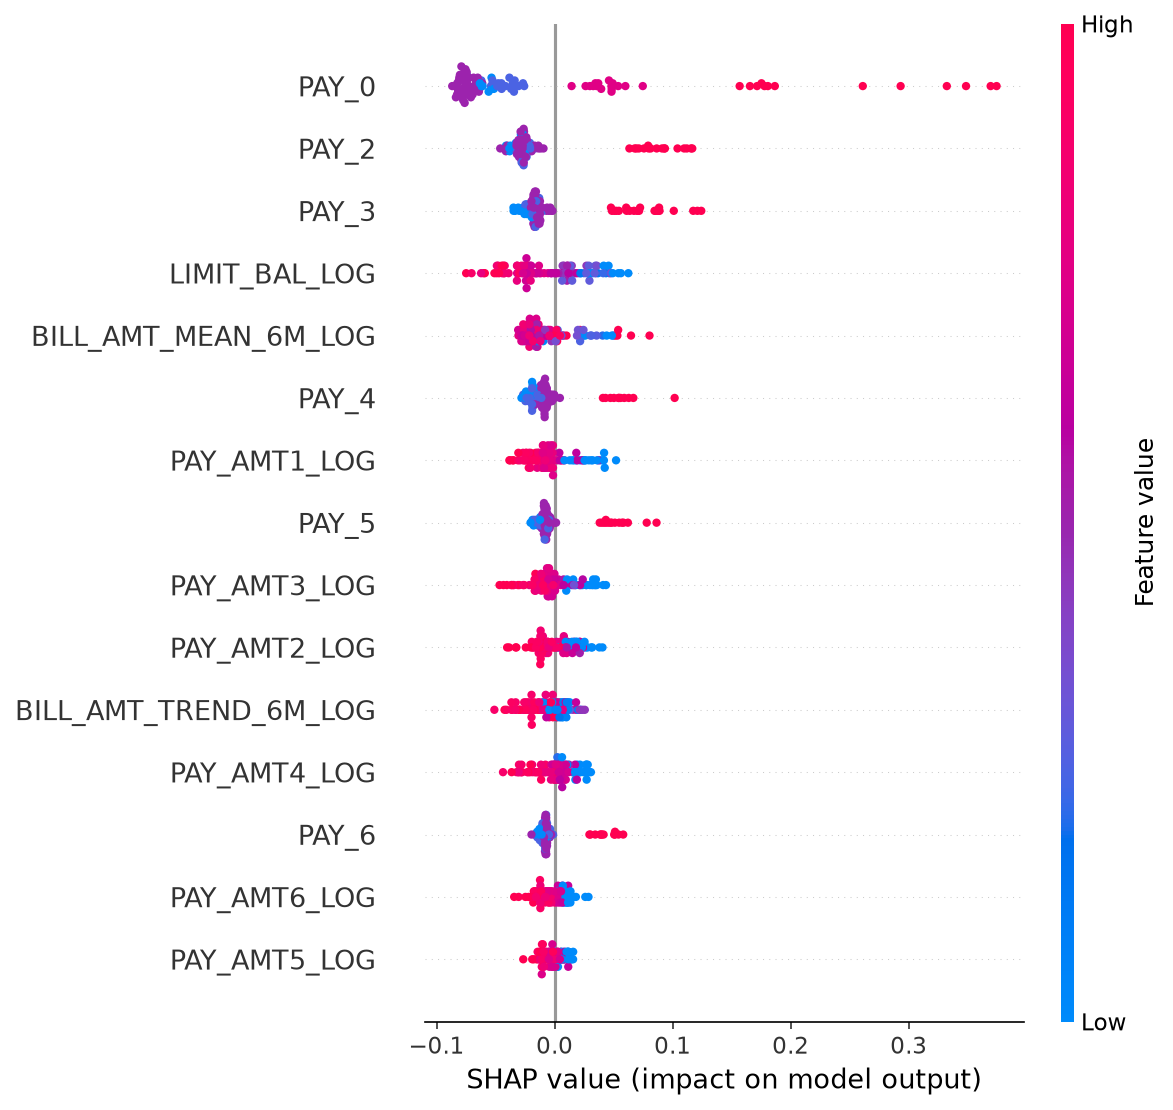

In [13]:
n_explain = min(ip.DEFAULT_N_EXPLAIN, fitted["X_test_t"].shape[0])

shap_values, base_value = ip.compute_shap_values(
    best_model, model_step, fitted["X_train_t"], fitted["X_test_t"][:n_explain]
)
agg_values, agg_names = ip.aggregate_onehot_shap(shap_values, fitted["feature_names"])
display_matrix = ip.build_aggregated_display_matrix(
    fitted["X_test"].iloc[:n_explain], fitted["X_test_t"][:n_explain], fitted["feature_names"]
)

summary_path = config.FIGURES_DIR / f"shap_summary_{best_model}.png"
ip.plot_shap_summary(agg_values, display_matrix, agg_names, save_path=str(summary_path))

from IPython.display import Image, display as ipy_display

ipy_display(Image(filename=str(summary_path)))

- **El historial de pagos domina.** `PAY_0` es la variable más importante, con una diferencia clara frente a las demás. Sus valores altos (meses de atraso) generan los aportes más grandes hacia *default*, de hasta cerca de +0.37. Le siguen `PAY_2` y `PAY_3`, y más abajo `PAY_4`, `PAY_5` y `PAY_6`. En todas ellas, más atraso aumenta el riesgo. Esto coincide con el EDA, con los coeficientes de la regresión logística base y con el SHAP preliminar del Random Forest.
- **Mayor límite de crédito, menor riesgo.** En `LIMIT_BAL_LOG` los valores altos (rojo) quedan a la izquierda, es decir, reducen la probabilidad de *default*. Esto es coherente con la diferencia de límites entre clientes con y sin *default* encontrada en el EDA.
- **Montos pagados.** En las variables `PAY_AMT*_LOG`, los clientes que pagaron más (rojo) tienden a tener aportes negativos, o sea menor riesgo. Su efecto individual es pequeño.
- **Facturación.** `BILL_AMT_MEAN_6M_LOG` aparece en quinto lugar y `BILL_AMT_TREND_6M_LOG` en un nivel más bajo, con un efecto moderado y menos claro que el de los pagos. Esto es consistente con el EDA, donde el monto facturado discriminaba poco entre clases.

## SHAP local: una observación bien clasificada y una con error alto

{'well_classified': 2555, 'high_error': 3936}
well_classified: y_true=1, y_pred=1, proba=0.982


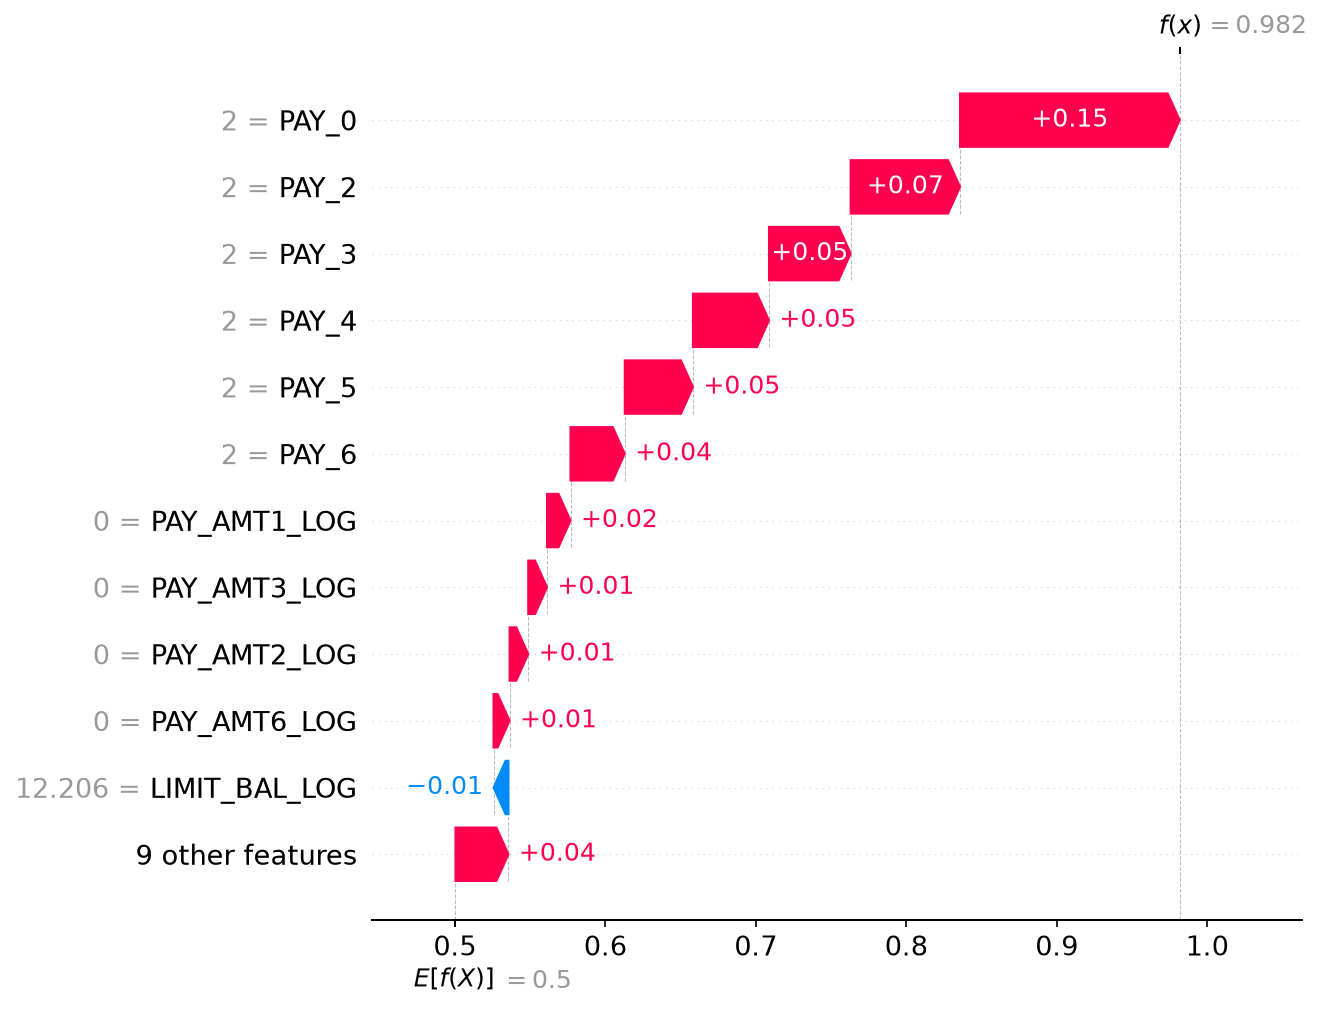

high_error: y_true=0, y_pred=1, proba=0.964


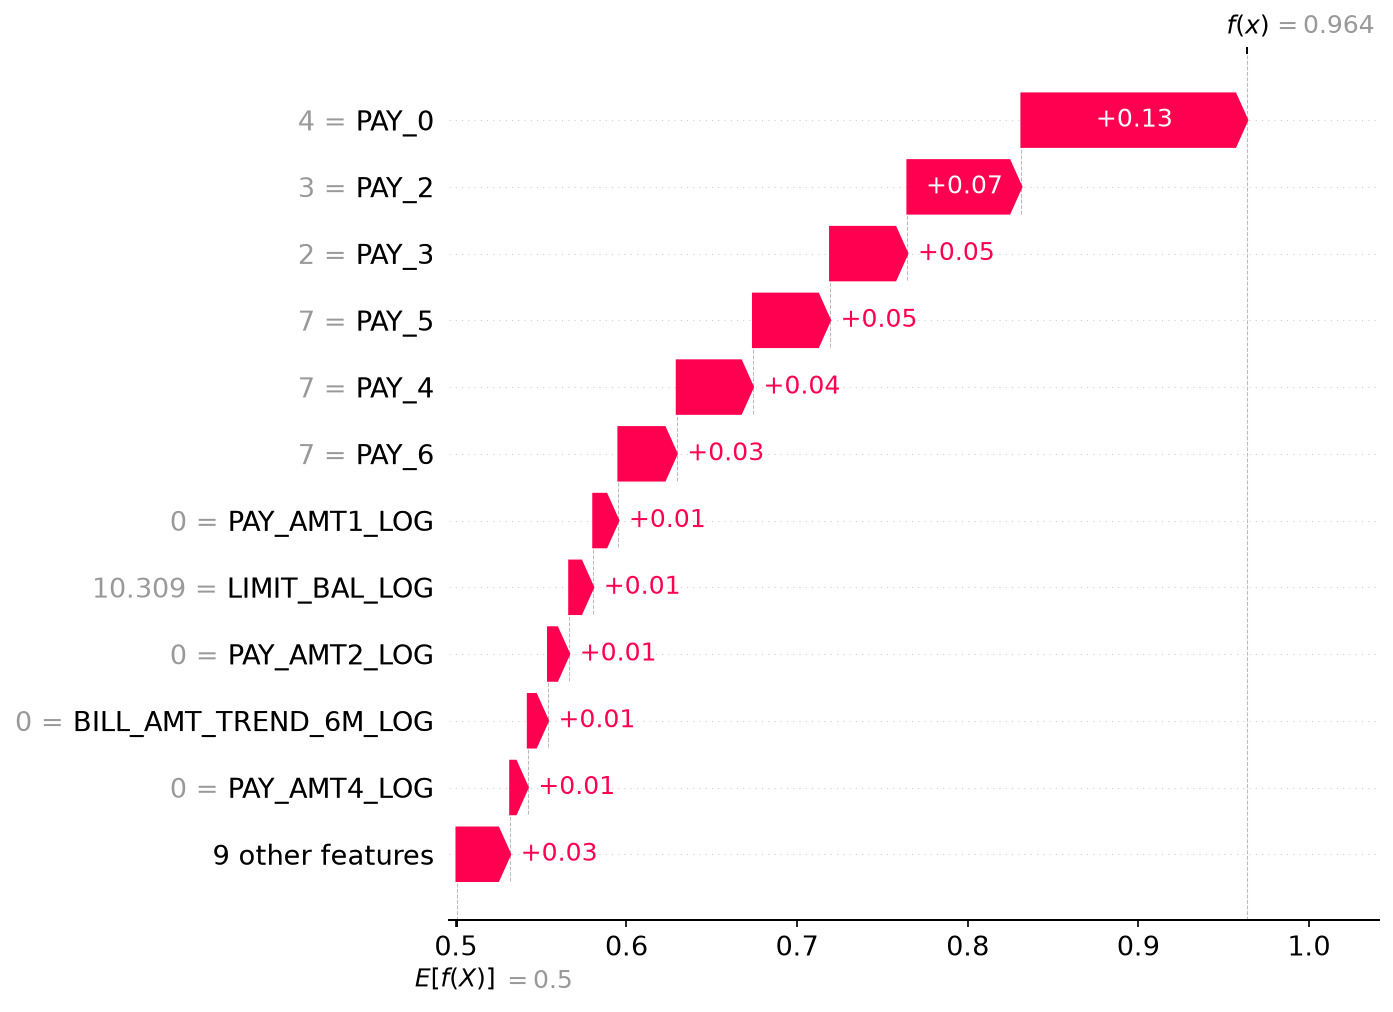

In [14]:
y_pred_test = fitted["pipeline"].predict(fitted["X_test"])
y_proba_test = fitted["pipeline"].predict_proba(fitted["X_test"])[:, 1]
instances = ip.select_representative_instances(fitted["y_test"].to_numpy(), y_pred_test, y_proba_test)
print(instances)

for label, pos in instances.items():
    x_row_t = fitted["X_test_t"][pos : pos + 1]
    sv, bv = ip.compute_shap_values(best_model, model_step, fitted["X_train_t"], x_row_t)
    agg_sv, agg_n = ip.aggregate_onehot_shap(sv, fitted["feature_names"])
    row_display = ip.build_aggregated_display_matrix(
        fitted["X_test"].iloc[pos : pos + 1], x_row_t, fitted["feature_names"]
    )
    waterfall_path = config.FIGURES_DIR / f"shap_waterfall_{best_model}_{label}.png"
    ip.plot_shap_waterfall(agg_sv[0], bv, row_display[0], agg_n, save_path=str(waterfall_path))
    print(
        f"{label}: y_true={fitted['y_test'].iloc[pos]}, y_pred={y_pred_test[pos]}, "
        f"proba={y_proba_test[pos]:.3f}"
    )
    ipy_display(Image(filename=str(waterfall_path)))

Se analizaron dos clientes del pliegue de prueba. El valor base del modelo es 0.5 y cada barra indica cuánto sube o baja la probabilidad predicha.

**1. Cliente bien clasificado** (*default* real = 1, predicho = 1, probabilidad = 0.982)

- Tiene un atraso de 2 meses en `PAY_0` y también en `PAY_2` a `PAY_6`, es decir, atrasos en los seis meses.
- Las seis variables `PAY` suman cerca de +0.41, lo que explica casi todo el aumento de 0.5 a 0.982. El mayor aporte es el de `PAY_0` (+0.15).
- No registra pagos (`PAY_AMT_LOG = 0`), lo que suma un poco más al riesgo.
- Su límite de crédito (`LIMIT_BAL_LOG` = 12.206, cercano a 200,000) es el único factor que lo reduce, y solo en −0.01.

El modelo acierta con mucha seguridad porque todas las señales importantes apuntan en la misma dirección.

**2. Cliente con error alto** (*default* real = 0, predicho = 1, probabilidad = 0.964)

- Es un falso positivo. Tiene atrasos en todos los meses (`PAY_0` = 4, `PAY_2` = 3, `PAY_3` = 2 y `PAY_4`, `PAY_5`, `PAY_6` = 7) y sin pagos registrados.
- Las seis variables `PAY` suman cerca de +0.37, con `PAY_0` como mayor aporte (+0.13). Según su historial, el modelo lo considera casi seguro de caer en *default*.
- Su historial es poco habitual: los atrasos pasan de 2 a 7 meses de un mes a otro. Esto podría indicar un registro atípico o con errores, pero con estos datos no se puede confirmar.

El error no parece venir de una falla del modelo, sino de un cliente que, con ese historial, no incumplió. Esto es consistente con el ruido que ya se había detectado en el EDA: hay clientes con las mismas variables y etiquetas distintas, por lo que ningún modelo puede acertar en todos los casos.


## LIME vs. SHAP (específicamente para XGBoost)

Si el mejor modelo ya es XGBoost, esta sección reutiliza el mismo ajuste de arriba; si no, ajusta la mejor combinación de XGBoost por separado (el curso pide esta comparación puntualmente para XGBoost, más allá de cuál haya resultado ser el mejor modelo global).

In [15]:
xgb_rows = table[table["model"] == "xgboost"]

if xgb_rows.empty:
    print(
        "No hay corridas de XGBoost en la tabla maestra todavía: "
        "correr 04_run_experiments.ipynb incluyendo xgboost para esta sección."
    )
else:
    xgb_best_row = xgb_rows.sort_values(f"{metric_for_ranking}_mean", ascending=False).iloc[0]
    xgb_technique = xgb_best_row["technique"]
    xgb_best_params_per_fold = json.loads(xgb_best_row["best_params_per_fold"])
    xgb_per_fold_metric = json.loads(xgb_best_row[f"{metric_for_ranking}_per_fold"])
    xgb_fold_idx = int(np.argmax(xgb_per_fold_metric))
    xgb_best_params = xgb_best_params_per_fold[xgb_fold_idx]

    xgb_spec = MODEL_REGISTRY["xgboost"]
    xgb_fitted = ip.fit_explainable_pipeline(
        xgb_spec, xgb_technique, xgb_best_params, X, y, xgb_fold_idx,
        n_outer_folds=int(xgb_best_row["n_outer_folds"]),
    )
    xgb_model_step = xgb_fitted["pipeline"].named_steps["model"]

    xgb_y_pred = xgb_fitted["pipeline"].predict(xgb_fitted["X_test"])
    xgb_y_proba = xgb_fitted["pipeline"].predict_proba(xgb_fitted["X_test"])[:, 1]
    xgb_instances = ip.select_representative_instances(
        xgb_fitted["y_test"].to_numpy(), xgb_y_pred, xgb_y_proba
    )

    pos = xgb_instances["high_error"]
    x_row_t = xgb_fitted["X_test_t"][pos : pos + 1]

    lime_exp = ip.explain_with_lime(
        xgb_model_step, xgb_fitted["X_train_t"], xgb_fitted["feature_names"], x_row_t
    )
    sv, bv = ip.compute_shap_values("xgboost", xgb_model_step, xgb_fitted["X_train_t"], x_row_t)
    comparison_table = ip.compare_shap_lime(sv[0], lime_exp, xgb_fitted["feature_names"])

    print(f"Observación 'high_error' (XGBoost, {xgb_technique}, fold {xgb_fold_idx}):")
    display(comparison_table)

Observación 'high_error' (XGBoost, class_weight, fold 2):


,feature,shap_value,lime_weight
0,remainder__PAY_0,1.245319,0.091352
1,remainder__PAY_2,0.314957,0.043534
2,remainder__PAY_3,0.232570,0.071247
3,remainder__PAY_6,0.178103,0.034266
4,remainder__PAY_4,0.173505,0.056531
5,remainder__PAY_5,0.133808,0.025168
6,remainder__BILL_AMT_TREND_6M_LOG,0.051481,0.021247
7,remainder__BILL_AMT_MEAN_6M_LOG,-0.048345,-0.025667
8,remainder__LIMIT_BAL_LOG,0.046637,NaN
9,remainder__AGE,0.042024,NaN


### Discusión: ¿cuándo divergen LIME y SHAP?

- **LIME** ajusta un modelo sustituto LINEAL (regularizado) sobre muestras perturbadas alrededor de la observación, ponderadas por cercanía: una aproximación local cuya validez depende del ancho del kernel y el número de muestras perturbadas.
- **SHAP** calcula valores de Shapley (teoría de juegos cooperativos): el aporte marginal promedio de cada feature sobre todas las coaliciones posibles. Para árboles, `TreeExplainer` los calcula de forma EXACTA, y satisface axiomas de consistencia que LIME no garantiza.

**Divergen quando:**
1. **Features correlacionadas** (ej. el bloque `BILL_AMT1`-`BILL_AMT6`, VIF alto según el EDA): SHAP reparte el crédito entre ellas; LIME (Lasso) puede anular una y sobre-atribuir a la otra.
2. **No linealidad local fuerte** (ej. el efecto no lineal de `PAY_0` que el EDA ya detectó): un sustituto lineal como el de LIME la aproxima mal; SHAP (exacto para árboles) la sigue reflejando correctamente.
3. **Sensibilidad a hiperparámetros de LIME** (ancho del kernel, nº de muestras): puede cambiar el ranking entre corridas; SHAP/TreeExplainer es determinístico.

